In [1]:
import warnings
warnings.filterwarnings('ignore')

### k-Means
- 대표적인 군집 알고리즘으로 군집의 중심을 찾는 작업
- 클러스터(cluster): 군집
- 클러스터링(clustering): 군집화 하는 작업
- k-Means에서 k값이 Hyper Parameter

In [2]:
import numpy as np

In [3]:
fruits = np.load("/kaggle/input/data-fruits/fruits.npy")
fruits.shape

(300, 100, 100)

In [4]:
# 3차원 데이터를 2차원 데이터로 변경하기
fruits_2d = fruits.reshape(-1, 100*100)
fruits_2d.shape

(300, 10000)

### k-Means Model

In [6]:
from sklearn.cluster import KMeans

In [8]:
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_2d)

KMeans(n_clusters=3, random_state=42)

In [9]:
# 군집화 Label 출력
km.labels_

array([2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], d

In [11]:
# 군집화한 cluster갯수와 각 cluster의 갯수 확인하기
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([111,  98,  91]))


In [12]:
count0 = 0
for i in km.labels_:
    if i == 0:
        count0 += 1

print(count0)

111


---
### 첫번째 클러스터 확인하기

In [13]:
import matplotlib.pyplot as plt

In [17]:
def draw_fruits(arr, ratio=1): # ratio:해상도 크기
    n = len(arr) # n은 샘플 갯수
    # 한줄에 10개씩 이미지를 그린다.
    rows = int(np.ceil(n/10)) # 올림처리
    # 행이 1개이면 열 갯수가 샘플갯수이고 그렇지 않으면 10개이다.
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows,
                            cols,
                            figsize=(cols*ratio, rows*ratio),
                            squeeze=False
                           )
    for i in range(rows):
        for j in range(cols):
            if i * 10 + j < n:
                axs[i, j].imshow(arr[i*10+j], cmap='gray_r')
            axs[i,j].axis('off')

    plt.show()
    

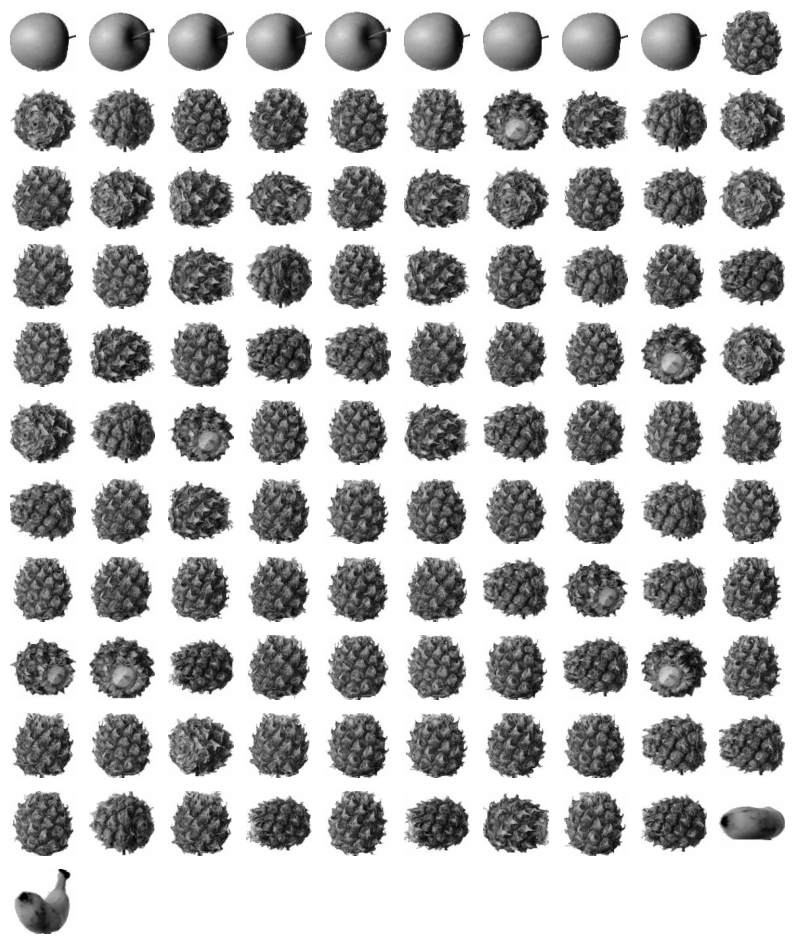

In [18]:
draw_fruits(fruits[km.labels_ == 0])

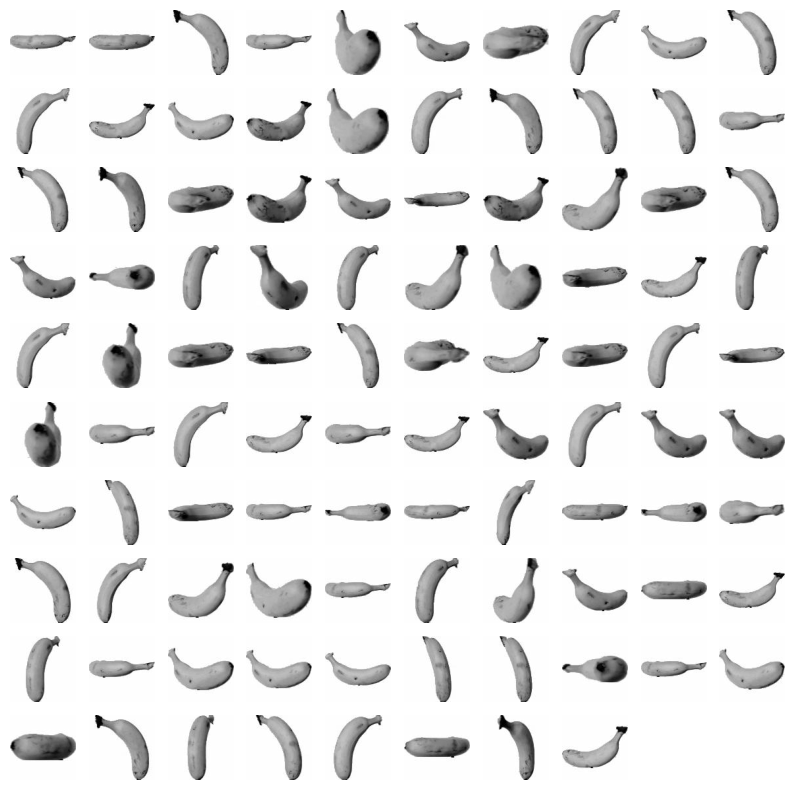

In [19]:
draw_fruits(fruits[km.labels_ == 1])

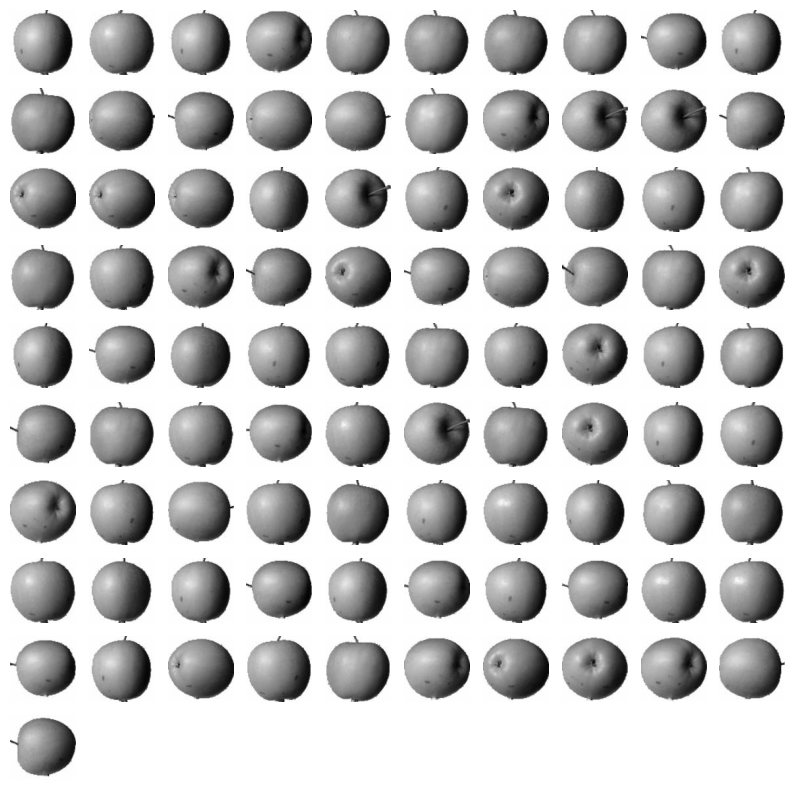

In [20]:
draw_fruits(fruits[km.labels_ == 2])

> 클러스터 0: 파인애플    
> 클러스터 1: 바나나    
> 클러스터 2: 애플

---
### 클러스터 중심

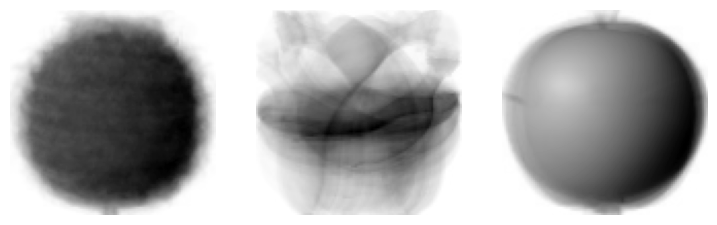

In [22]:
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=3)

In [23]:
# 100번째의 예측 군집값
print(km.predict(fruits_2d[100:101]))

[0]


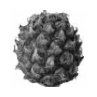

In [25]:
# 그림으로 확인하기
draw_fruits(fruits[100:101])

In [26]:
# 현재의 kMeans의 반복횟수 값 확인
km.n_iter_

4

> 기본 반복횟수는 300번이나 현재 4번안에 최적의 값을 찾았다는 의미

---
### 최적의 k 찾기
: kMeans에서는 k가 Hyper Parameter이므로 k값을 찾는 것이 중요하다.

### Elbow Method(최적의 군집수 구하기)
: cluster간의 거리의 합을 나타내는 관성 구간이 급격이 떨어지는 포인트 찾기

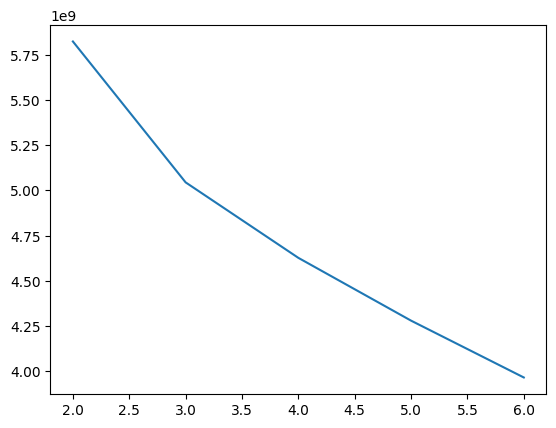

In [28]:
inertia = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(fruits_2d)
    inertia.append(km.inertia_)

plt.plot(range(2,7), inertia)
plt.show()